In [49]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed
from src.utils.experiment_utils import find_experiment_by_name

# Importar as funções
from src.result_analysis.plots import ( plot_predictions_with_context,)

from src.result_analysis.metrics import (compute_flow_metrics,print_metrics_summary)

from src import ConfigLoader, load_config

from src import save_predictions, save_plot
from src.utils.experiment_utils import convert_predictions_to_df

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed_inference"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed_inference


In [50]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

experiment_name = data_config["experiment_name"]
stations = data_config["stations"]


⚙️ Carregando configurações...


### Importação de dados OBS

In [51]:
pasta = Path(r"C:/Users/emily/Documents/Dados_previsao_operacao/dados_previsoes_passadas/operacao_2026_03_23")

def carregar_series_completas():
    dados = {}
    
    for arquivo in pasta.glob("*_complete_date_inference.csv"):
        
        estacao = arquivo.name.split("_")[0]
        
        try:
            df = pd.read_csv(
                arquivo,
                parse_dates=['date']
            )
        except Exception as e:
            print(f"Erro ao ler {arquivo.name}: {e}")
            continue
        
        if df.empty:
            print(f"Aviso: {arquivo.name} está vazio.")
            continue
        
        df = df.sort_values('date').reset_index(drop=True)
        
        dados[estacao] = df
        
        print(f"Estação {estacao}: {len(df)} registros carregados.")
    
    return dados

In [52]:
dados_historicos = carregar_series_completas()

Estação 10100000: 36 registros carregados.
Estação 14100000: 36 registros carregados.


### Importação de dados previstos

In [53]:
# Passar diretório das previsões manualmente
#preds_dir = Path("C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/outputs/experiments/exp_003_Improve_model_performance_adjustment_freerun_gatemax/predictions_operational/raw")

# Último experimento
exp_path = find_experiment_by_name(experiment_name)
preds_dir = exp_path / "predictions_operational/raw"

csv_files = sorted(preds_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Nenhum modelo encontrado em {preds_dir}. Salve o modelo com save_checkpoint primeiro.")
model_path = csv_files[0]

In [54]:
def carregar_previsoes():
    
    df = pd.read_csv(
        model_path,
        parse_dates=['date']
    )
    
    # Garante ordenação
    df = df.sort_values('date').reset_index(drop=True)
    
    print(f"Previsões carregadas: {len(df)} dias")
    print(df.head())
    
    return df

In [55]:
def organizar_previsoes_por_estacao(df_previsoes):
    """
    Converte:
    date | Q_pred_10100000 | Q_pred_14100000
    
    → dict:
    {
        '10100000': df(date, Q_pred),
        ...
    }
    """
    
    previsoes_dict = {}
    
    for col in df_previsoes.columns:
        if col.startswith("Q_pred_"):
            
            estacao = col.replace("Q_pred_", "")
            
            df_est = df_previsoes[['date', col]].copy()
            df_est.rename(columns={col: 'Q_pred'}, inplace=True)
            
            previsoes_dict[estacao] = df_est
    
    return previsoes_dict

In [56]:
# 2. Previsões
df_previsoes = carregar_previsoes()

# 3. Organizar previsões
previsoes_dict = organizar_previsoes_por_estacao(df_previsoes)

Previsões carregadas: 15 dias
        date  Q_pred_10100000  Q_pred_13150000  Q_pred_14100000
0 2026-03-17        55189.270        98855.836       103772.086
1 2026-03-18        54978.430        99043.250       103842.875
2 2026-03-19        54821.080        99240.030       103976.680
3 2026-03-20        54683.293        99434.180       104136.190
4 2026-03-21        54534.850        99611.790       104293.055


### Plotagem dos Dados

In [57]:
def plot_operacional(dados_historicos, previsoes_dict, stations):
    """
    Plota observado vs previsto em subplots (um por estação),
    mantendo o padrão de cores original.
    """
    
    n = len(stations)
    
    if n == 0:
        print("Lista de estações vazia.")
        return
    
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n), sharex=True)
    
    if n == 1:
        axes = [axes]
    
    for i, st in enumerate(stations):
        
        ax = axes[i]
        
        # Compatibilidade int/str
        st_key = st if st in dados_historicos or st in previsoes_dict else str(st)
        
        df_obs = dados_historicos.get(st_key)
        df_pred = previsoes_dict.get(st_key)
        
        if df_pred is None:
            ax.set_title(f'Estação {st} — sem previsão')
            continue
        
        # ==========================
        # PREVISÃO (azul tracejado)
        # ==========================
        df_pred = df_pred.copy()
        df_pred['date'] = pd.to_datetime(df_pred['date'])
        df_pred = df_pred.sort_values('date')
        
        ax.plot(
            df_pred['date'],
            df_pred['Q_pred'],
            color='royalblue',
            linestyle='--',
            linewidth=2,
            label='Previsão'
        )
        
        forecast_start = df_pred['date'].min()
        ax.axvline(
            forecast_start,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='Início da previsão'
        )
        
        # ==========================
        # OBSERVADO (preto)
        # ==========================
        if df_obs is not None:
            df_obs = df_obs.copy()
            df_obs['date'] = pd.to_datetime(df_obs['date'])
            df_obs = df_obs.sort_values('date')
            
            ax.plot(
                df_obs['date'],
                df_obs['mean_Q'],
                color='black',
                linewidth=2,
                label='Observado'
            )
        
        # ==========================
        # FORMATAÇÃO
        # ==========================
        ax.set_title(f'Estação {st} — Observado vs Previsão', fontweight='bold')
        ax.set_ylabel('Vazão (m³/s)')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    axes[-1].set_xlabel('Data')
    
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

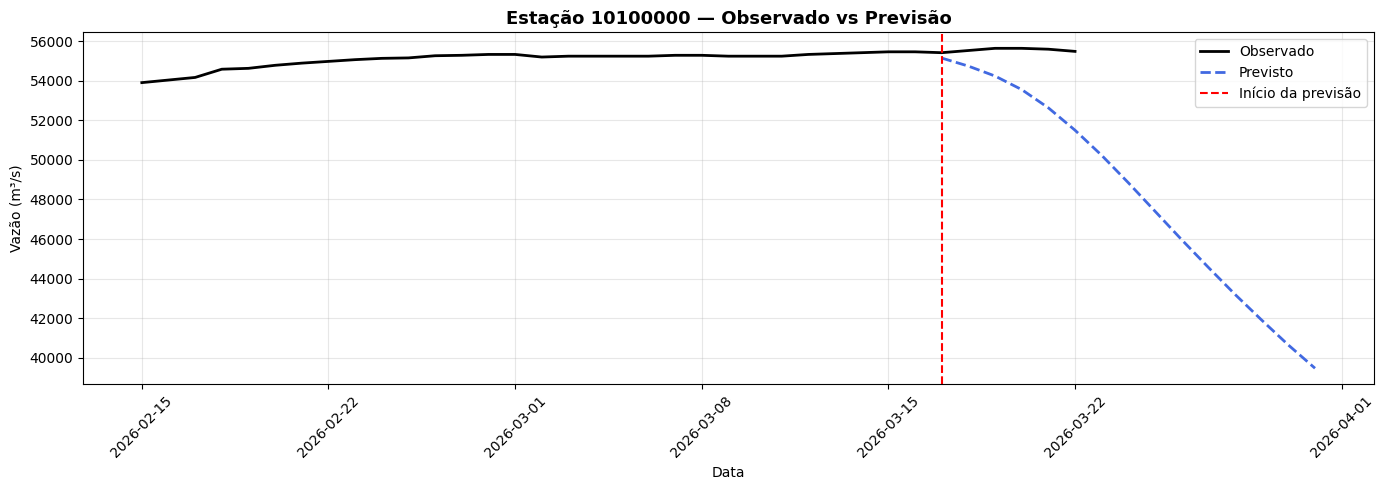

Estação 13050000 sem dados históricos.


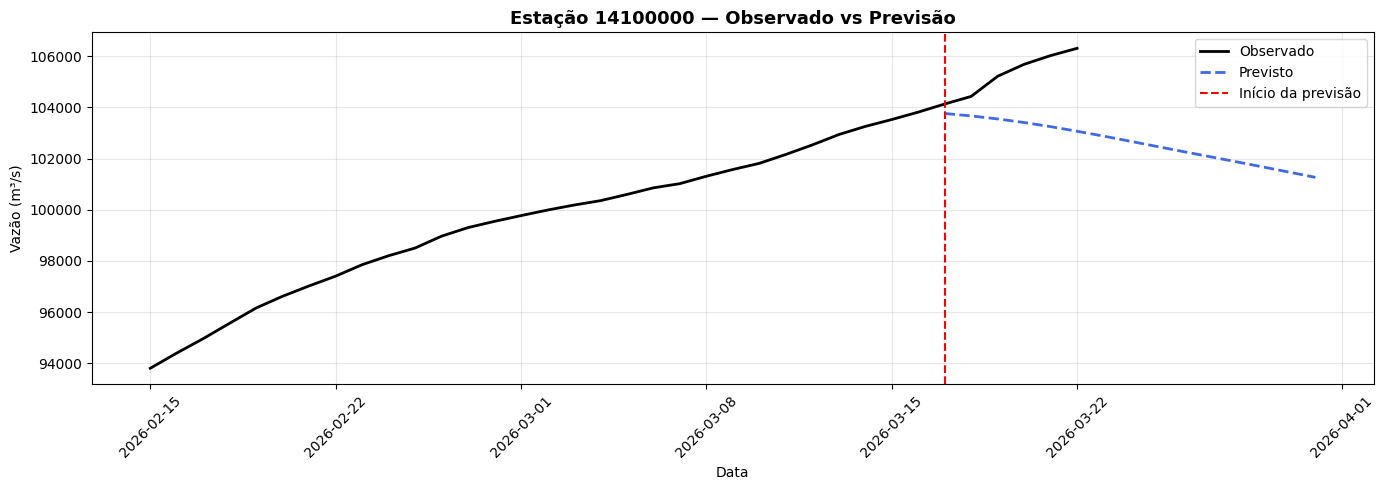

In [16]:
plot_operacional(dados_historicos, previsoes_dict, stations)

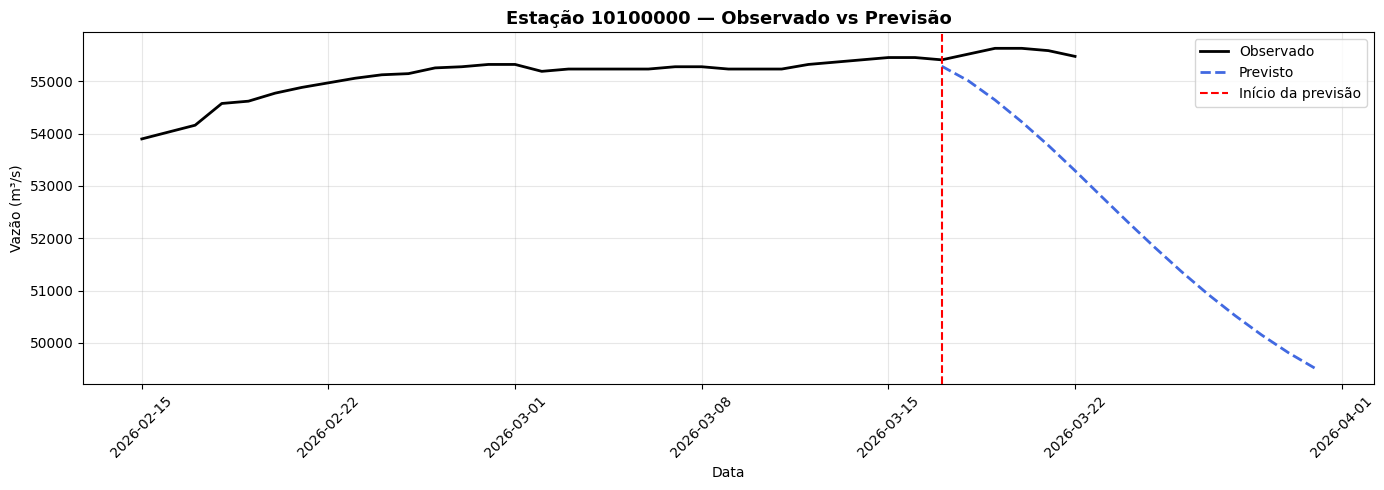

Estação 13050000 sem dados históricos.


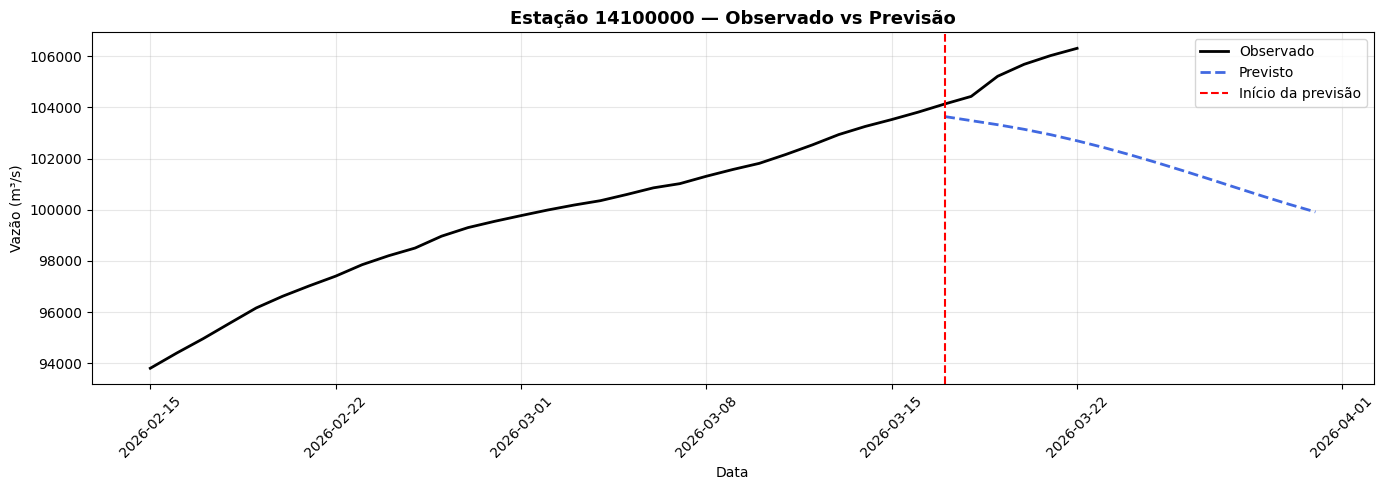

In [10]:
plot_operacional(dados_historicos, previsoes_dict, stations)

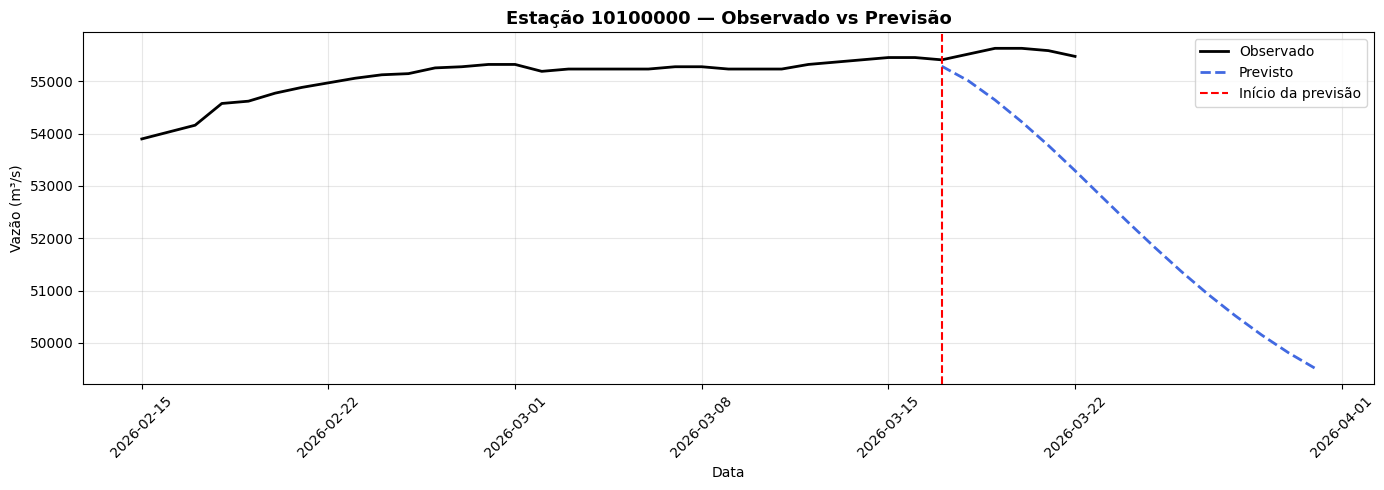

Estação 13050000 sem dados históricos.


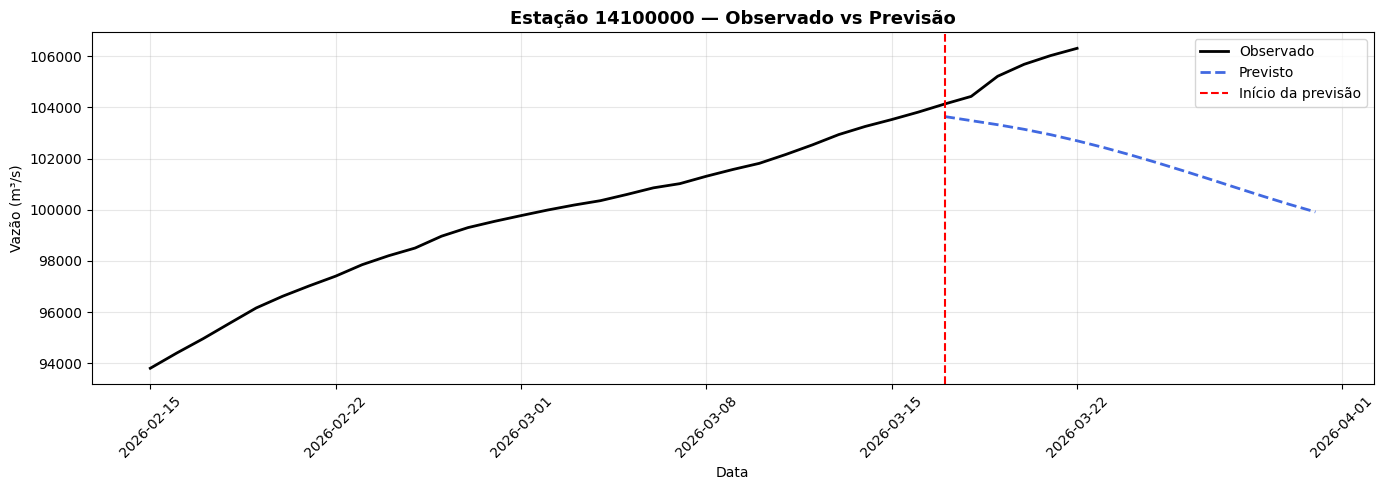

In [11]:
plot_operacional(dados_historicos, previsoes_dict, stations)

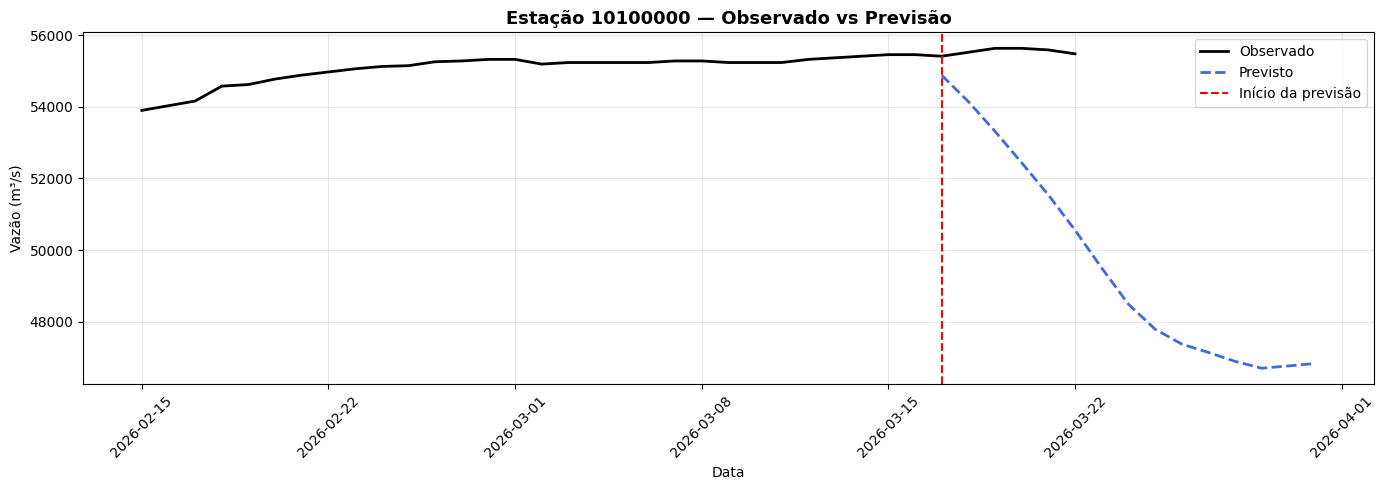

Estação 13050000 sem dados históricos.


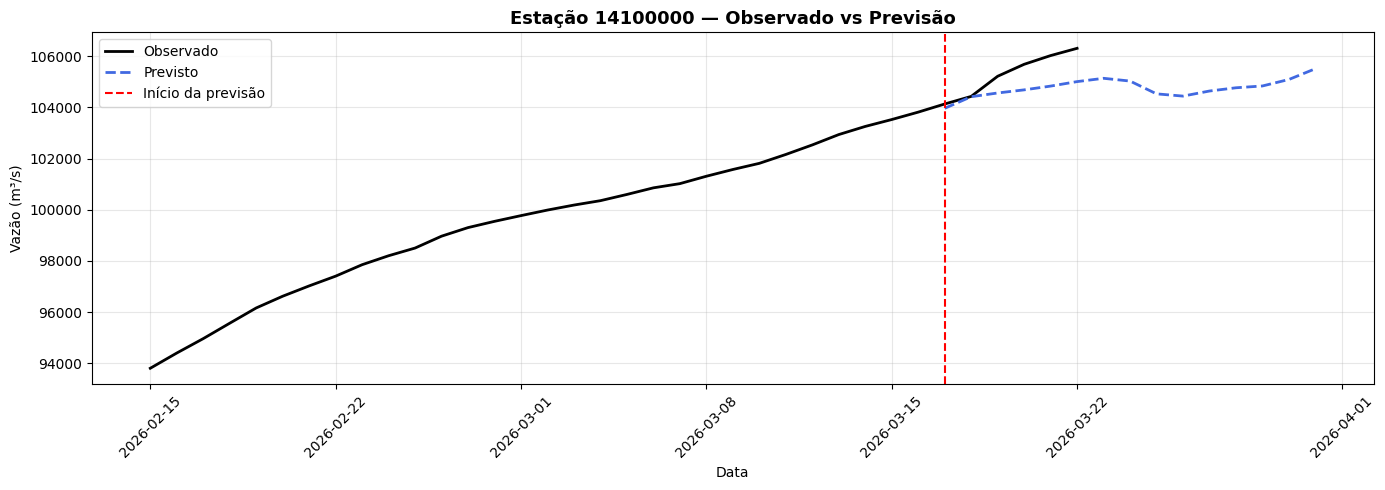

In [15]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 07

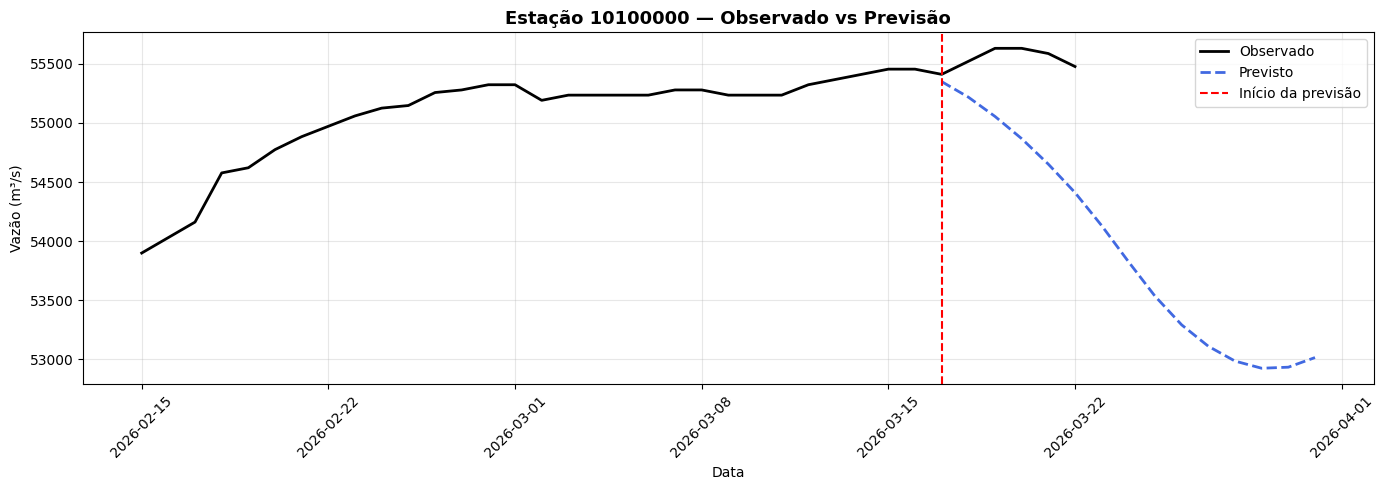

Estação 13050000 sem dados históricos.


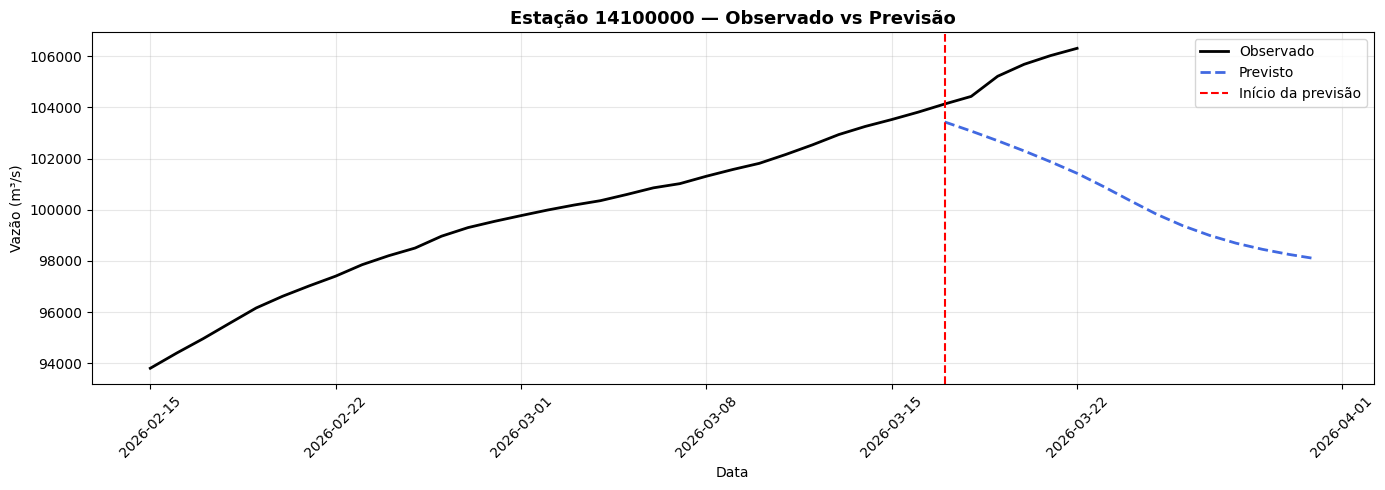

In [20]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 08

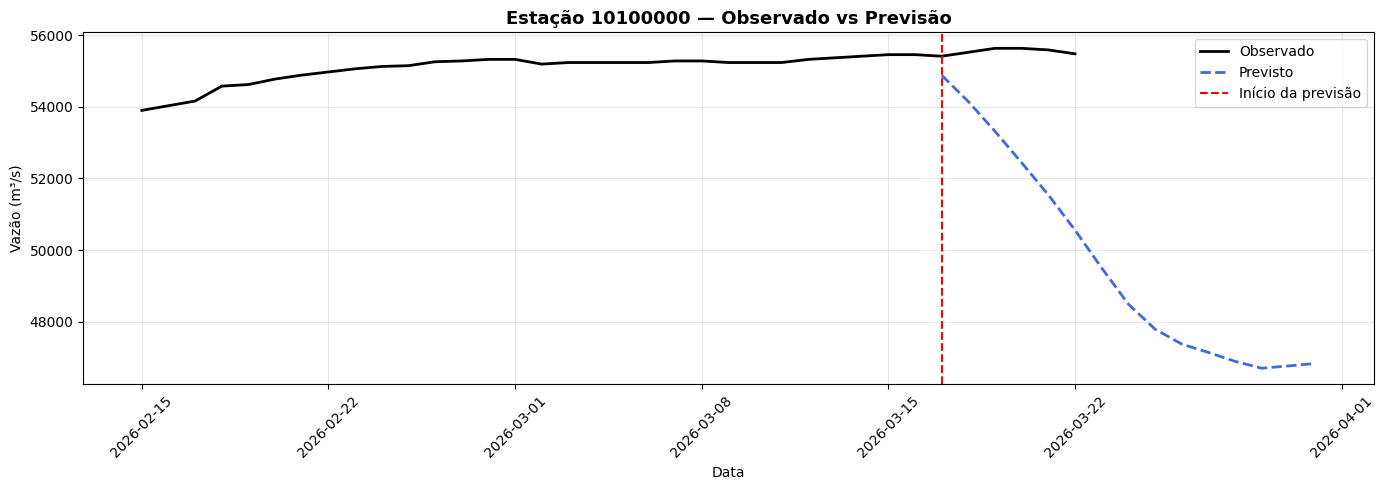

Estação 13150000 sem dados históricos.


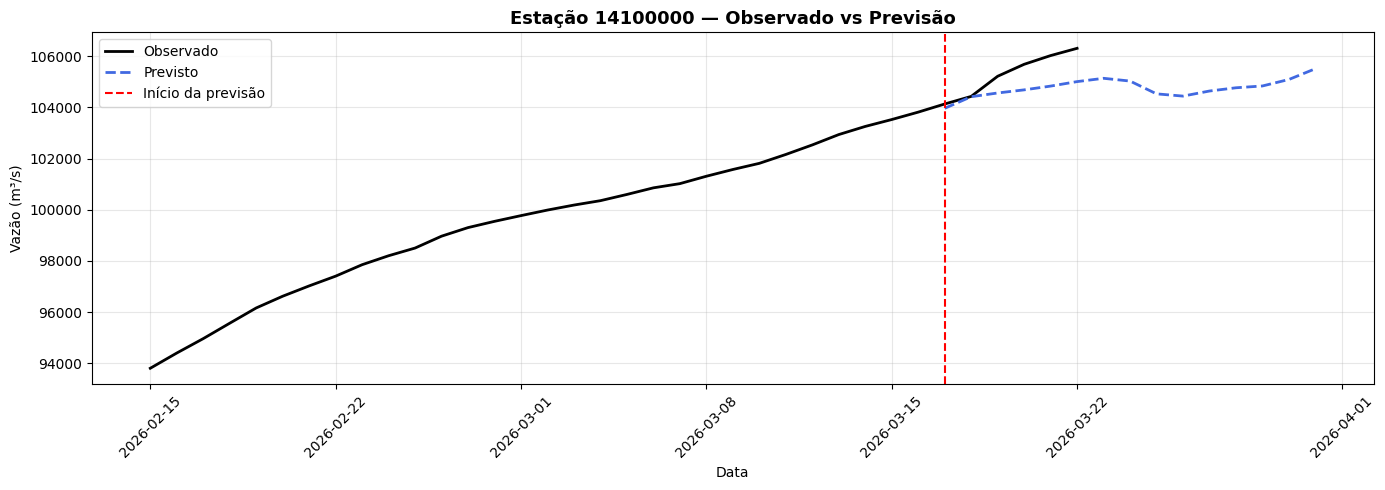

In [ ]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 09

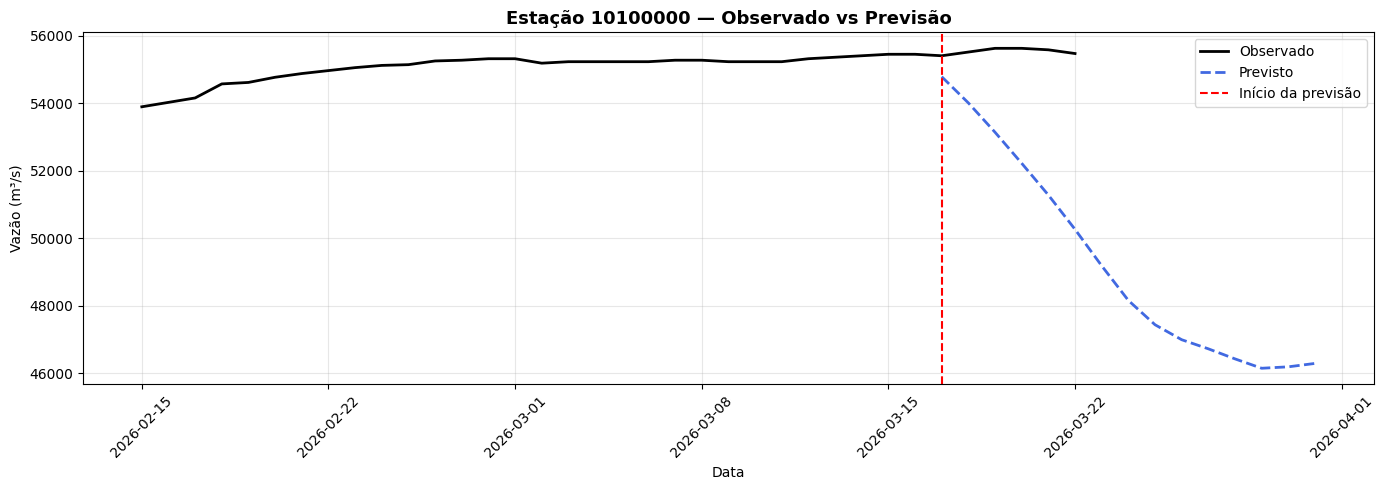

Estação 13150000 sem dados históricos.


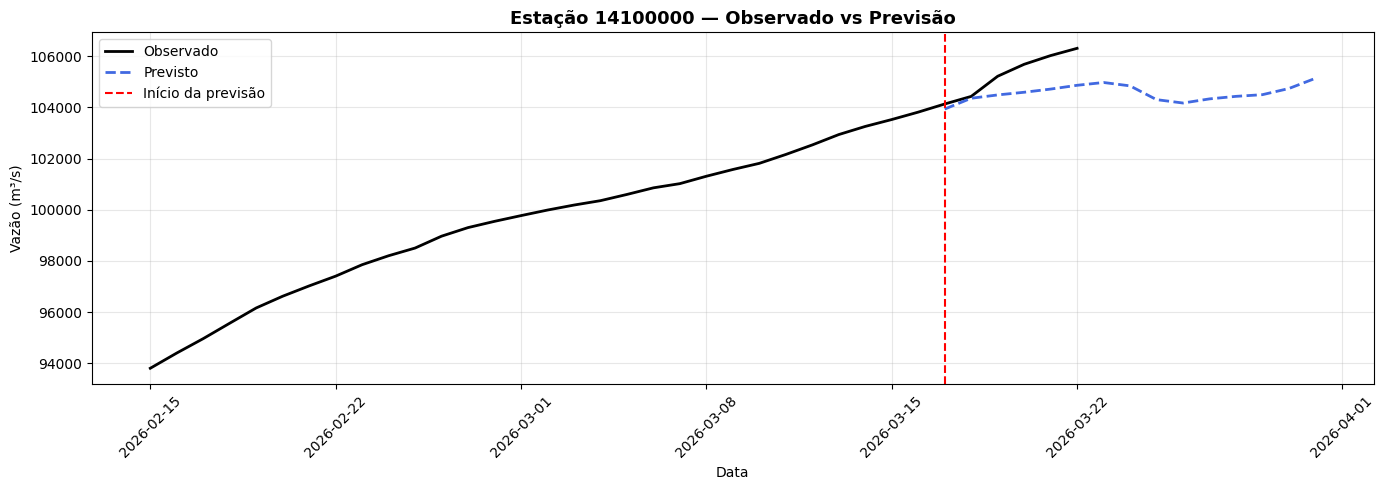

In [ ]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 11

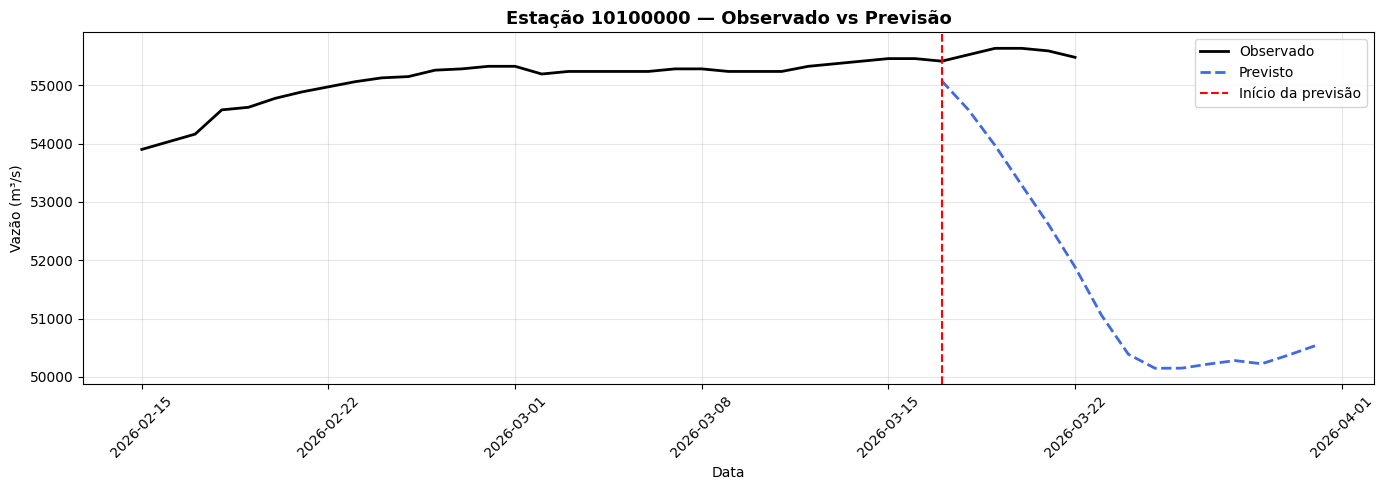

Estação 13150000 sem dados históricos.


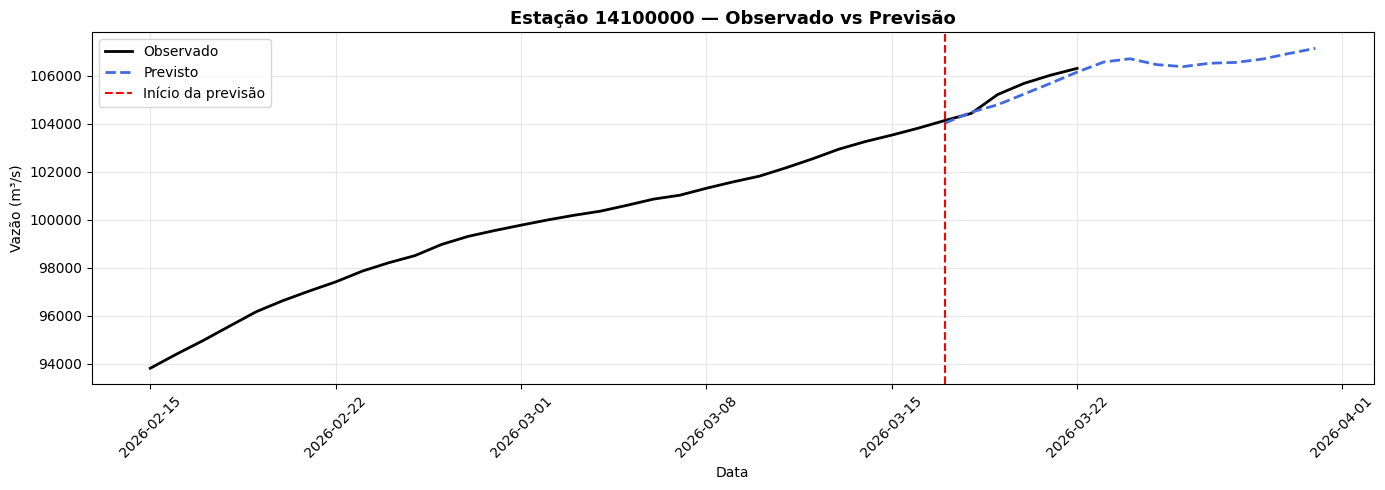

In [ ]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 13

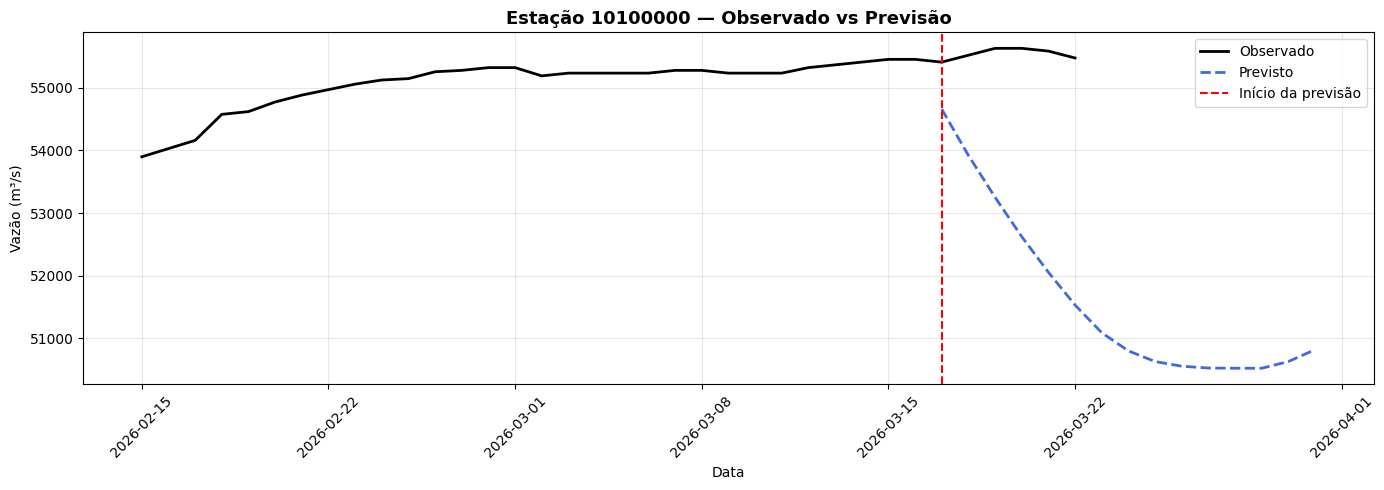

Estação 13150000 sem dados históricos.


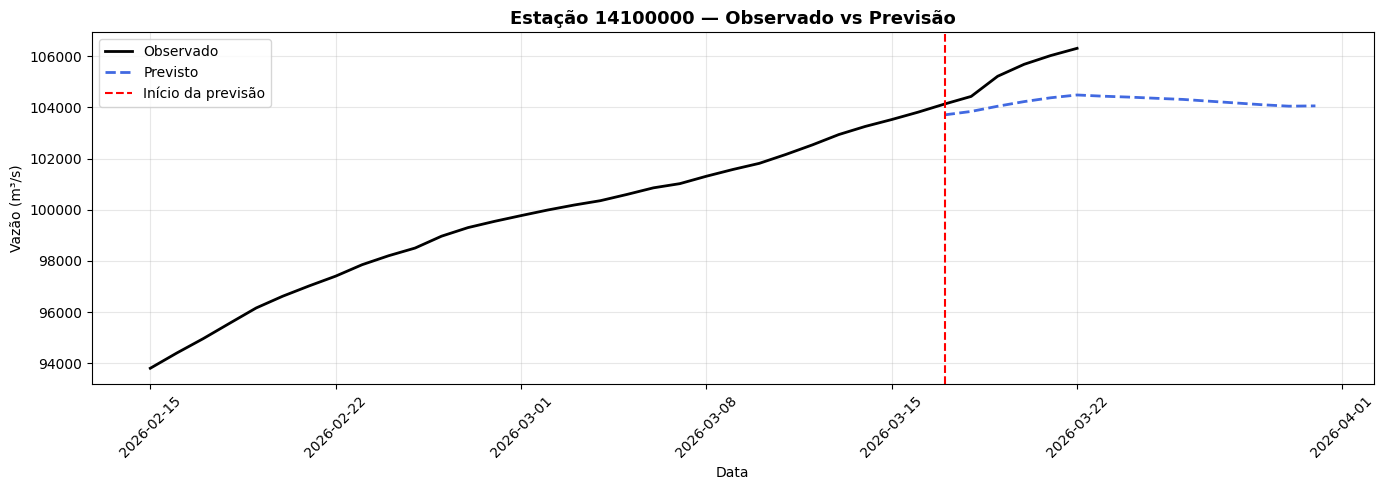

In [ ]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 15

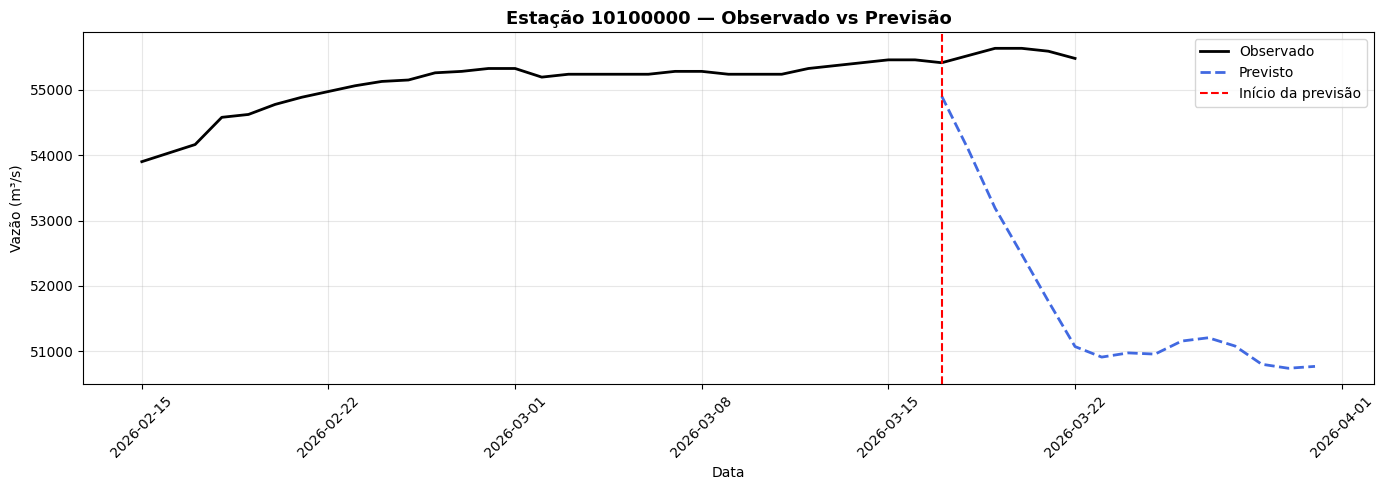

Estação 13150000 sem dados históricos.


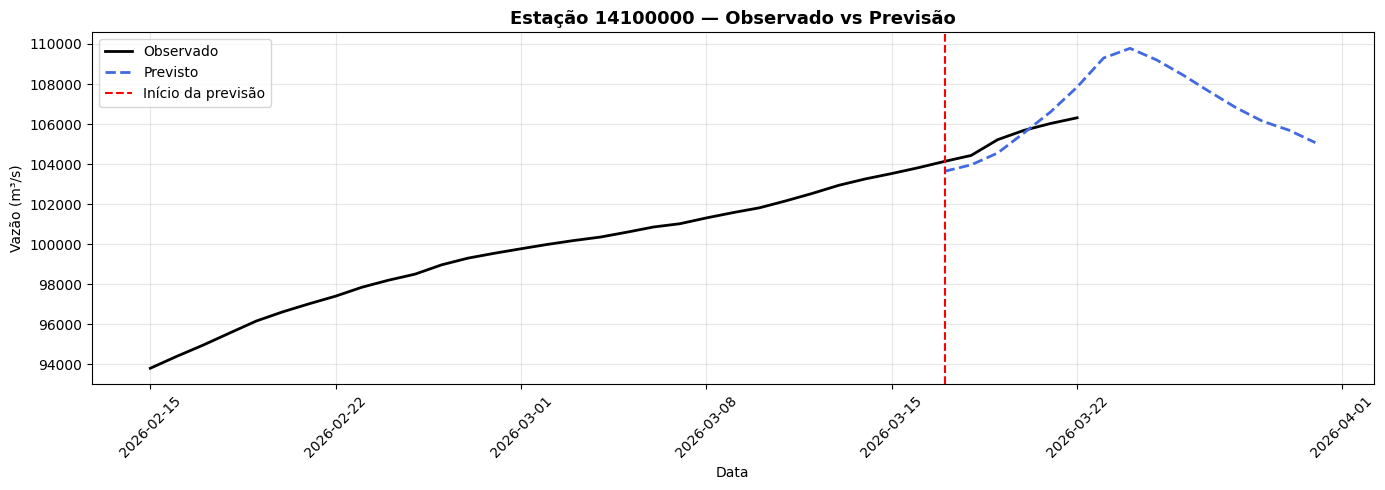

In [109]:
stations = ['10100000', '13150000', '14100000']
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 16

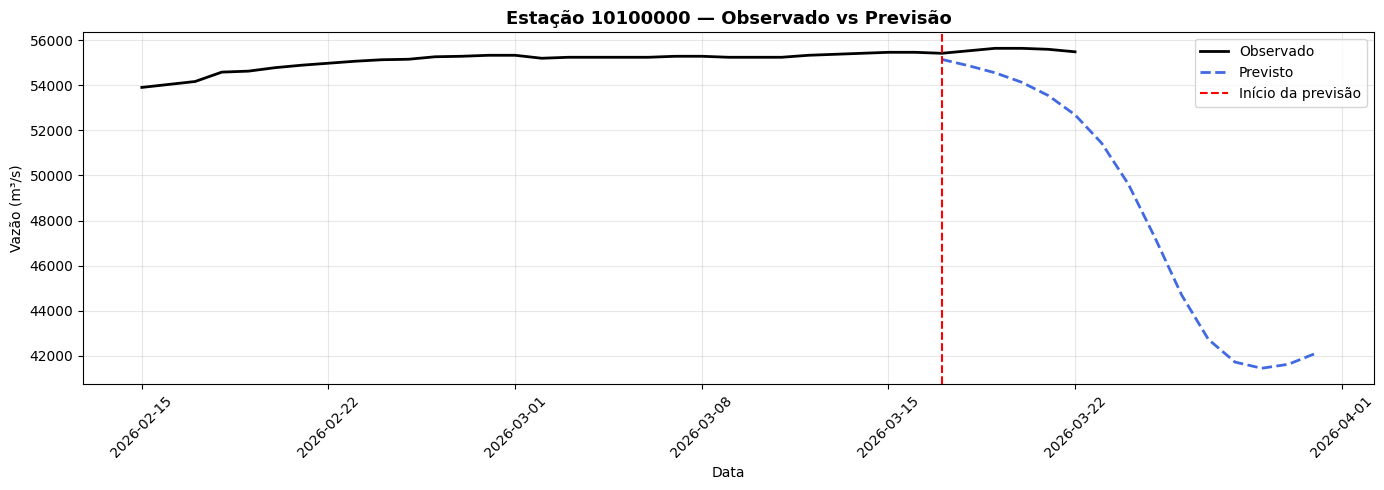

Estação 13150000 sem dados históricos.


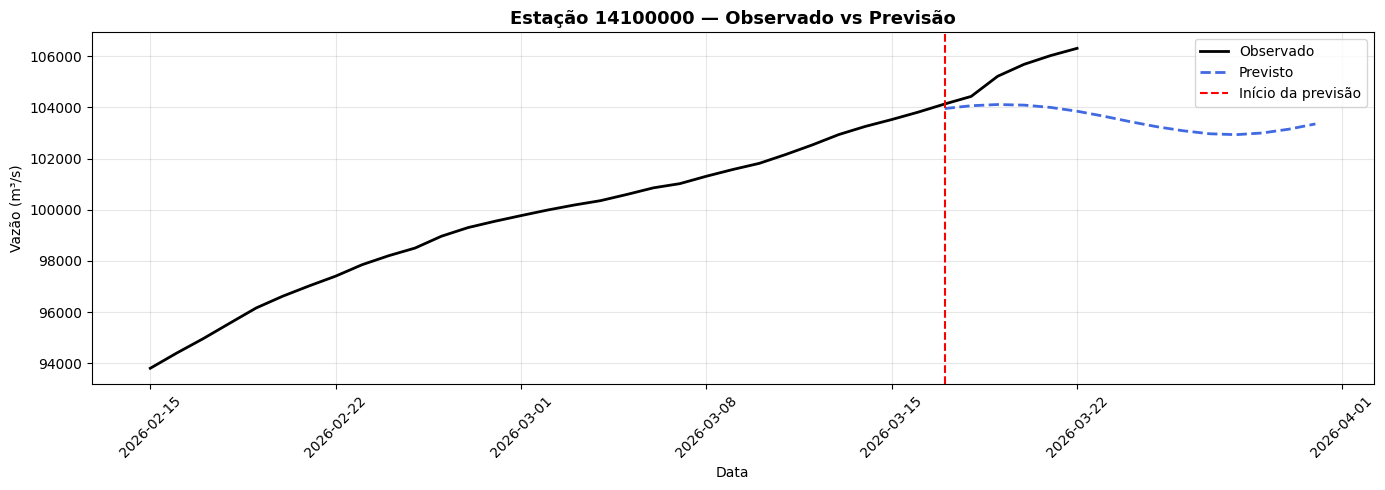

In [ ]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 20

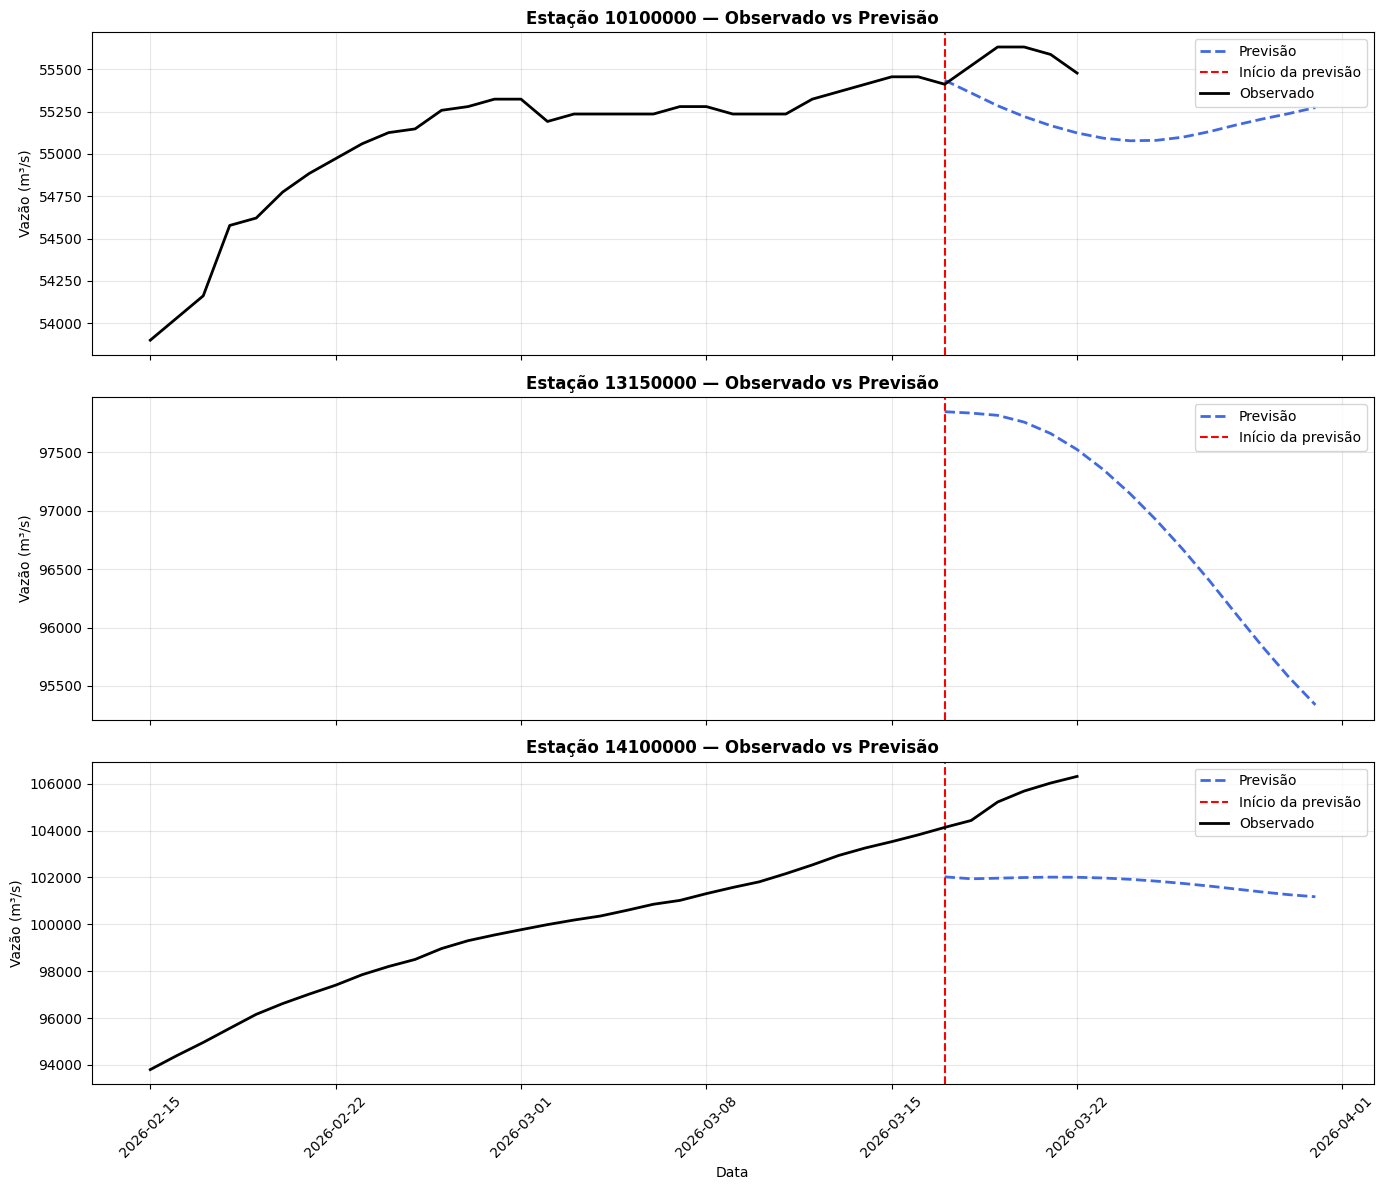

In [27]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 21 pessimo

### Exp 22

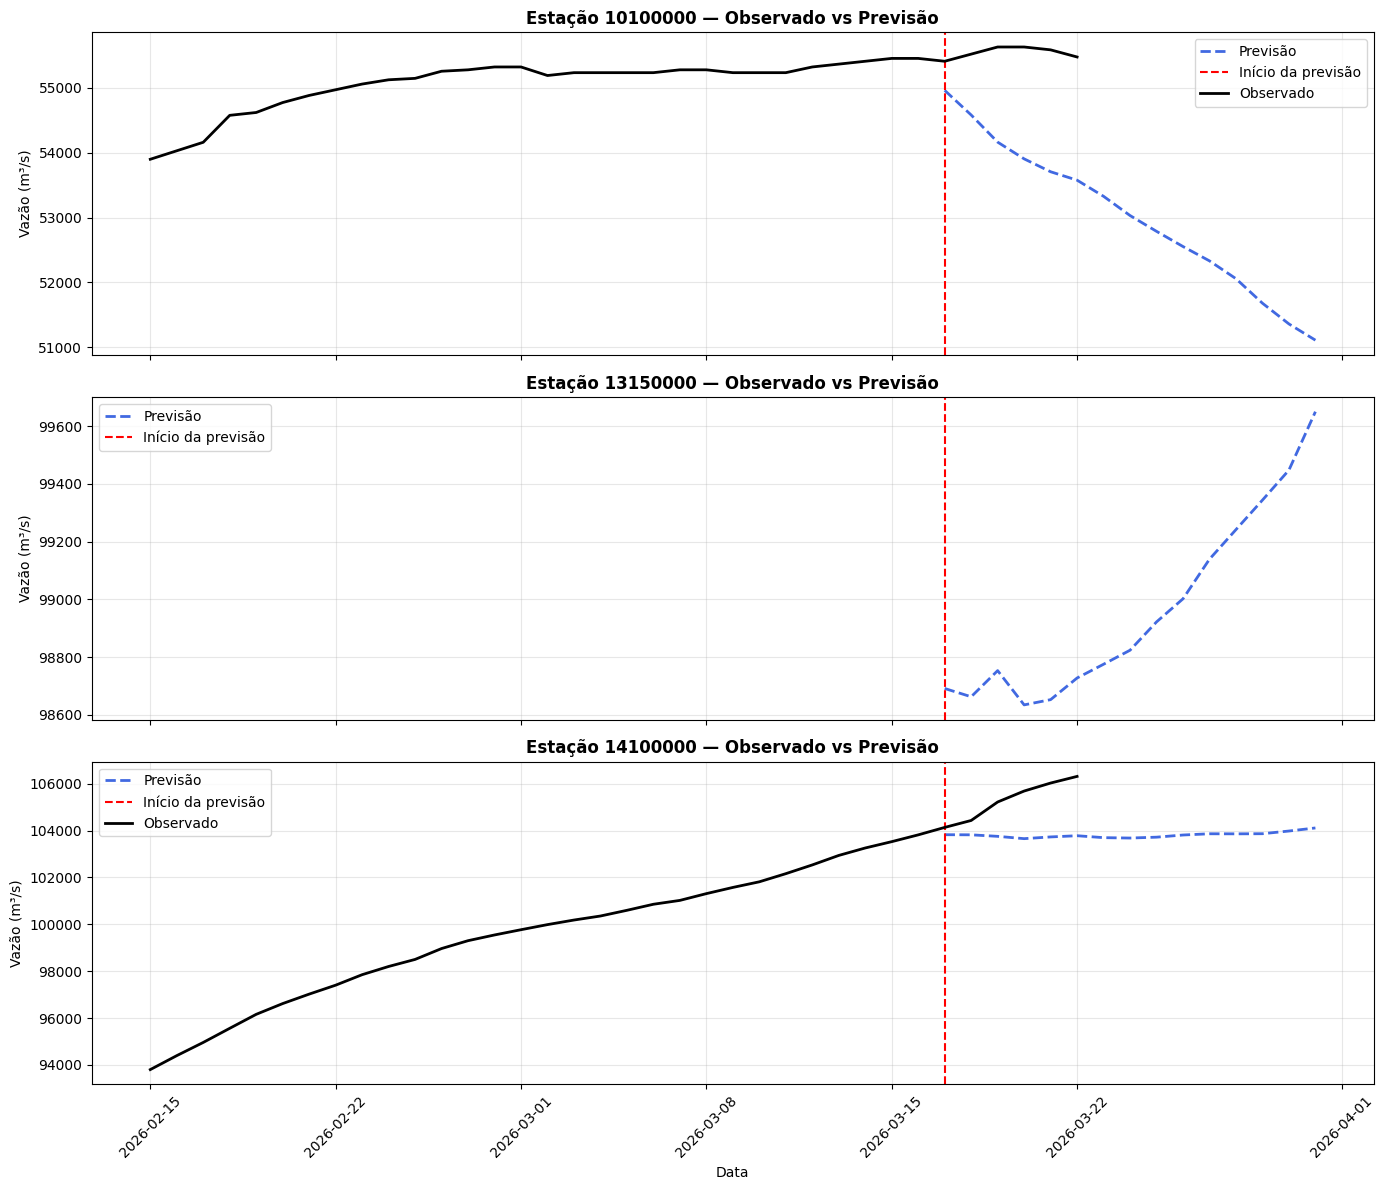

In [11]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 23

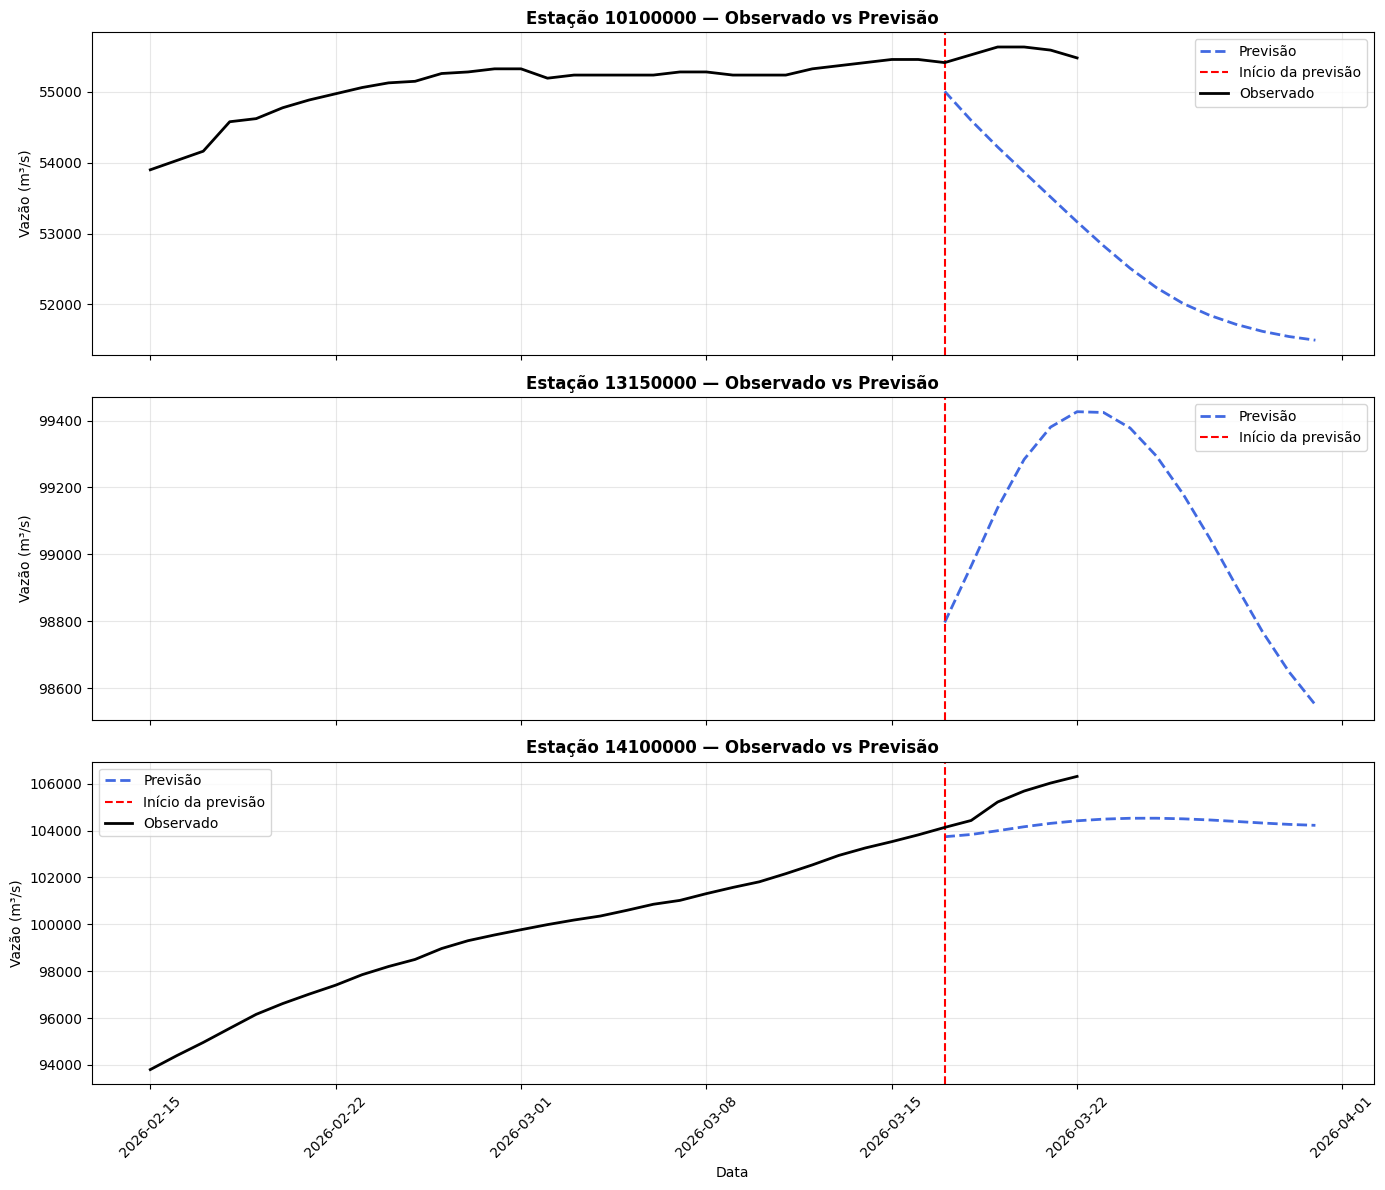

In [21]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 24

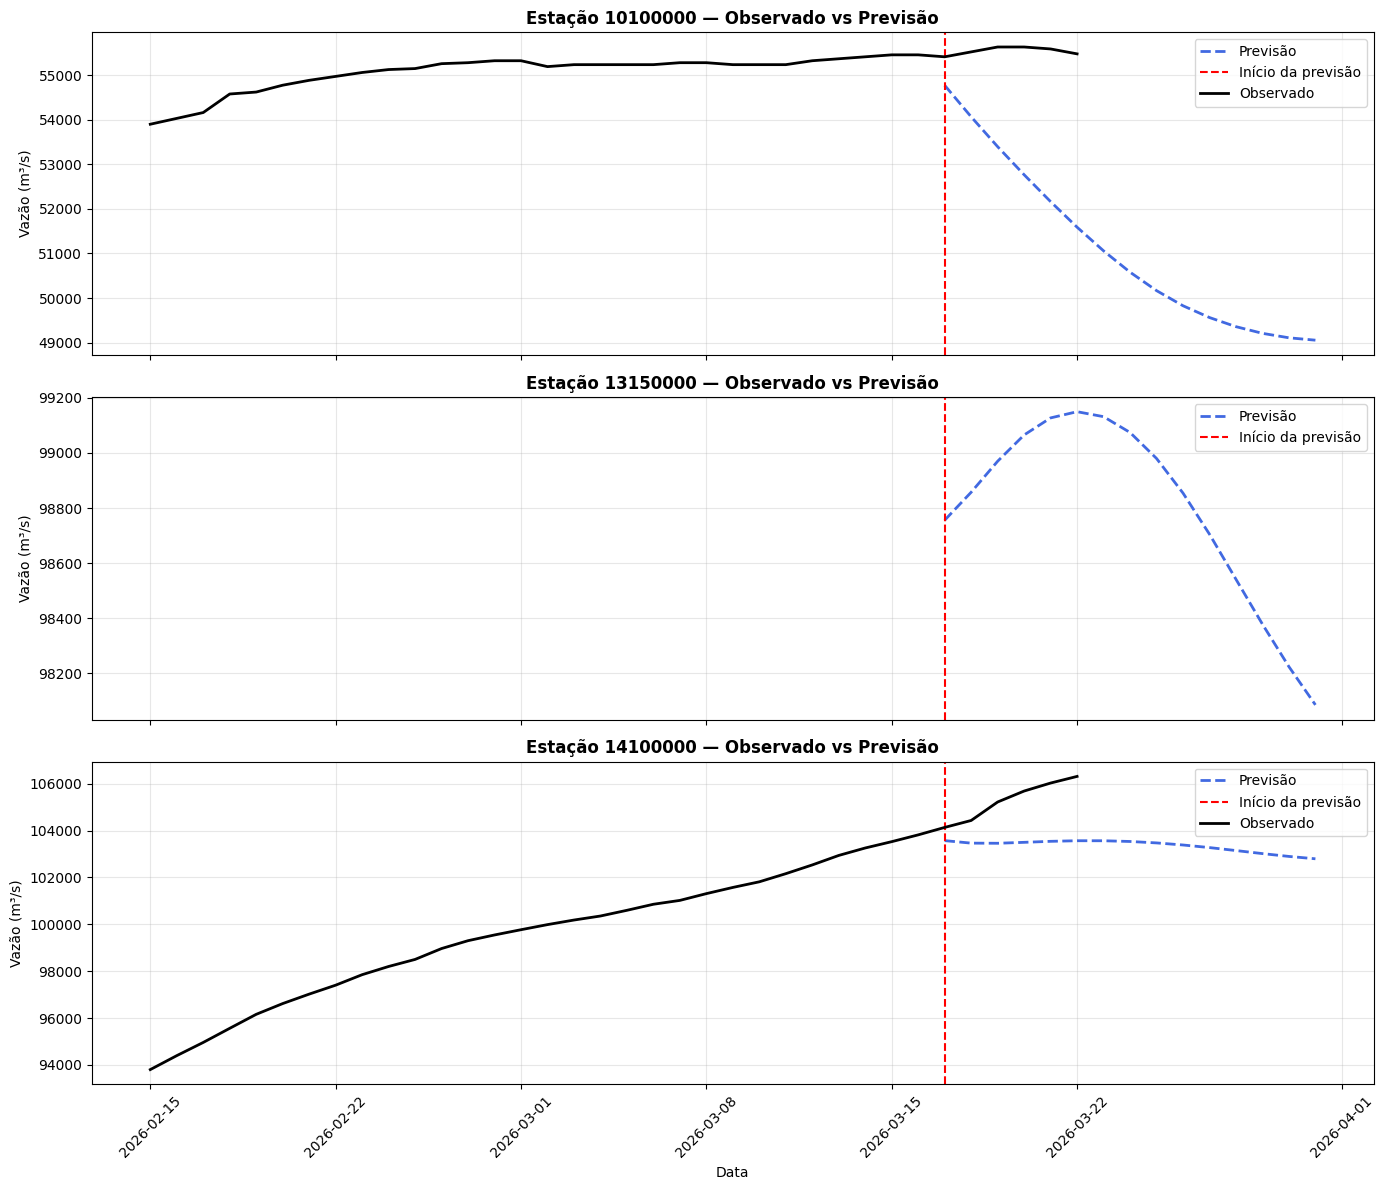

In [38]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 24

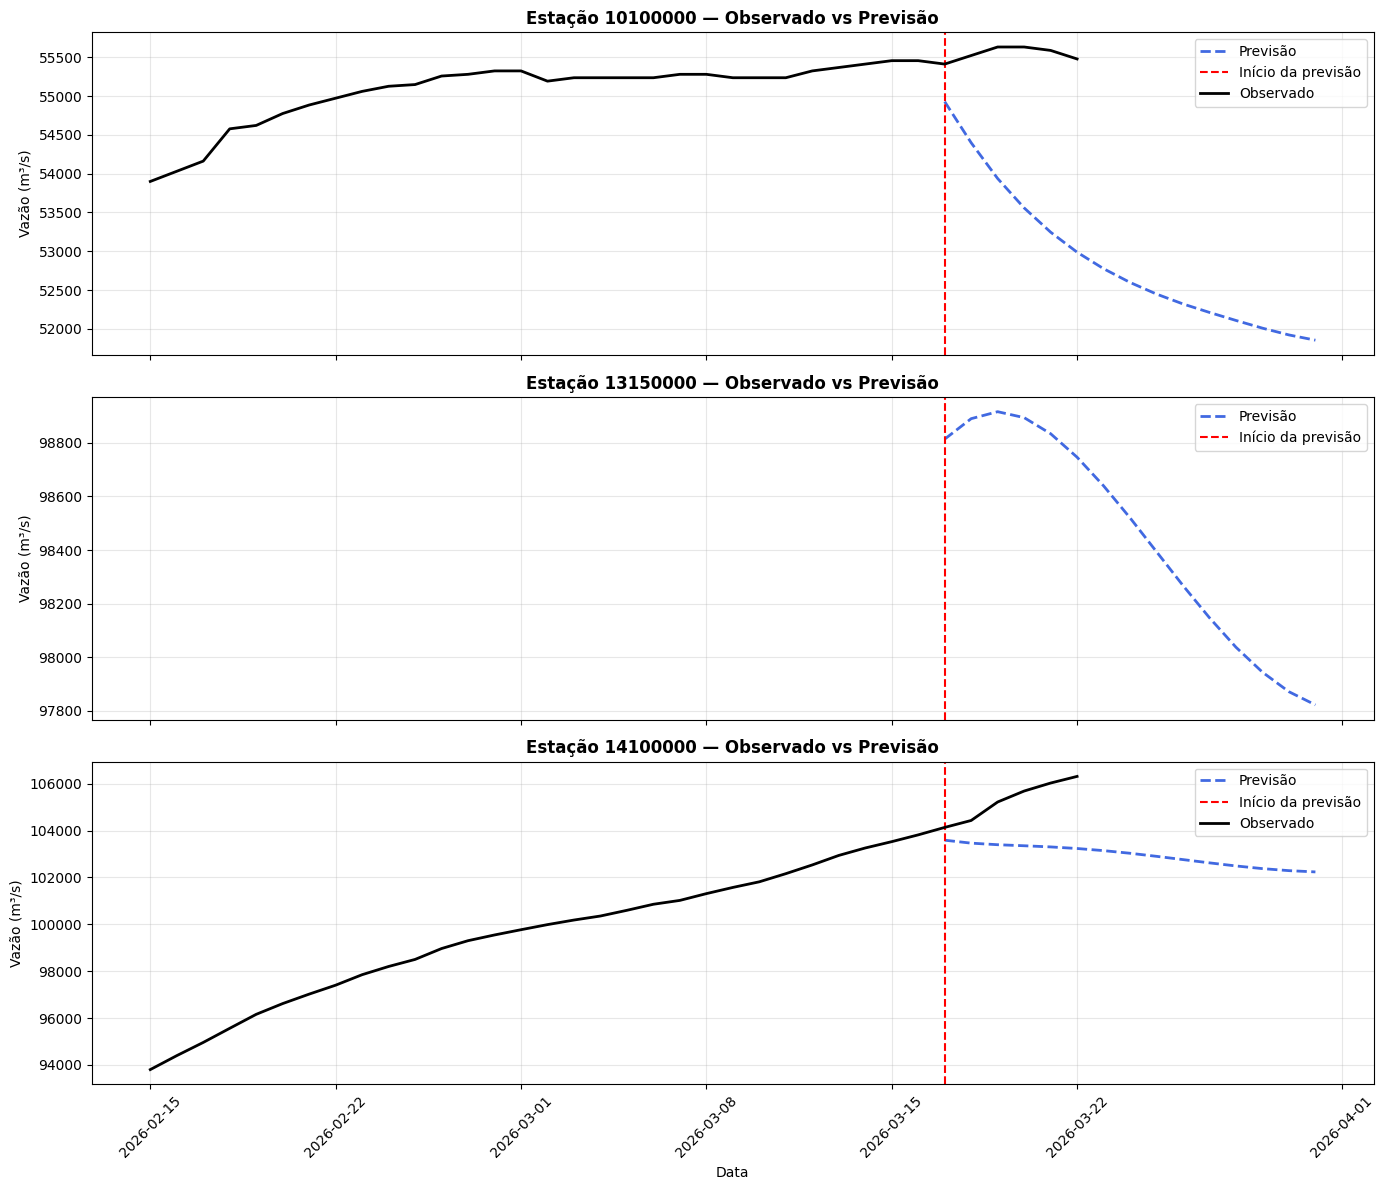

In [48]:
plot_operacional(dados_historicos, previsoes_dict, stations)

### Exp 25 foi com parâmetros errados

### Exp 26

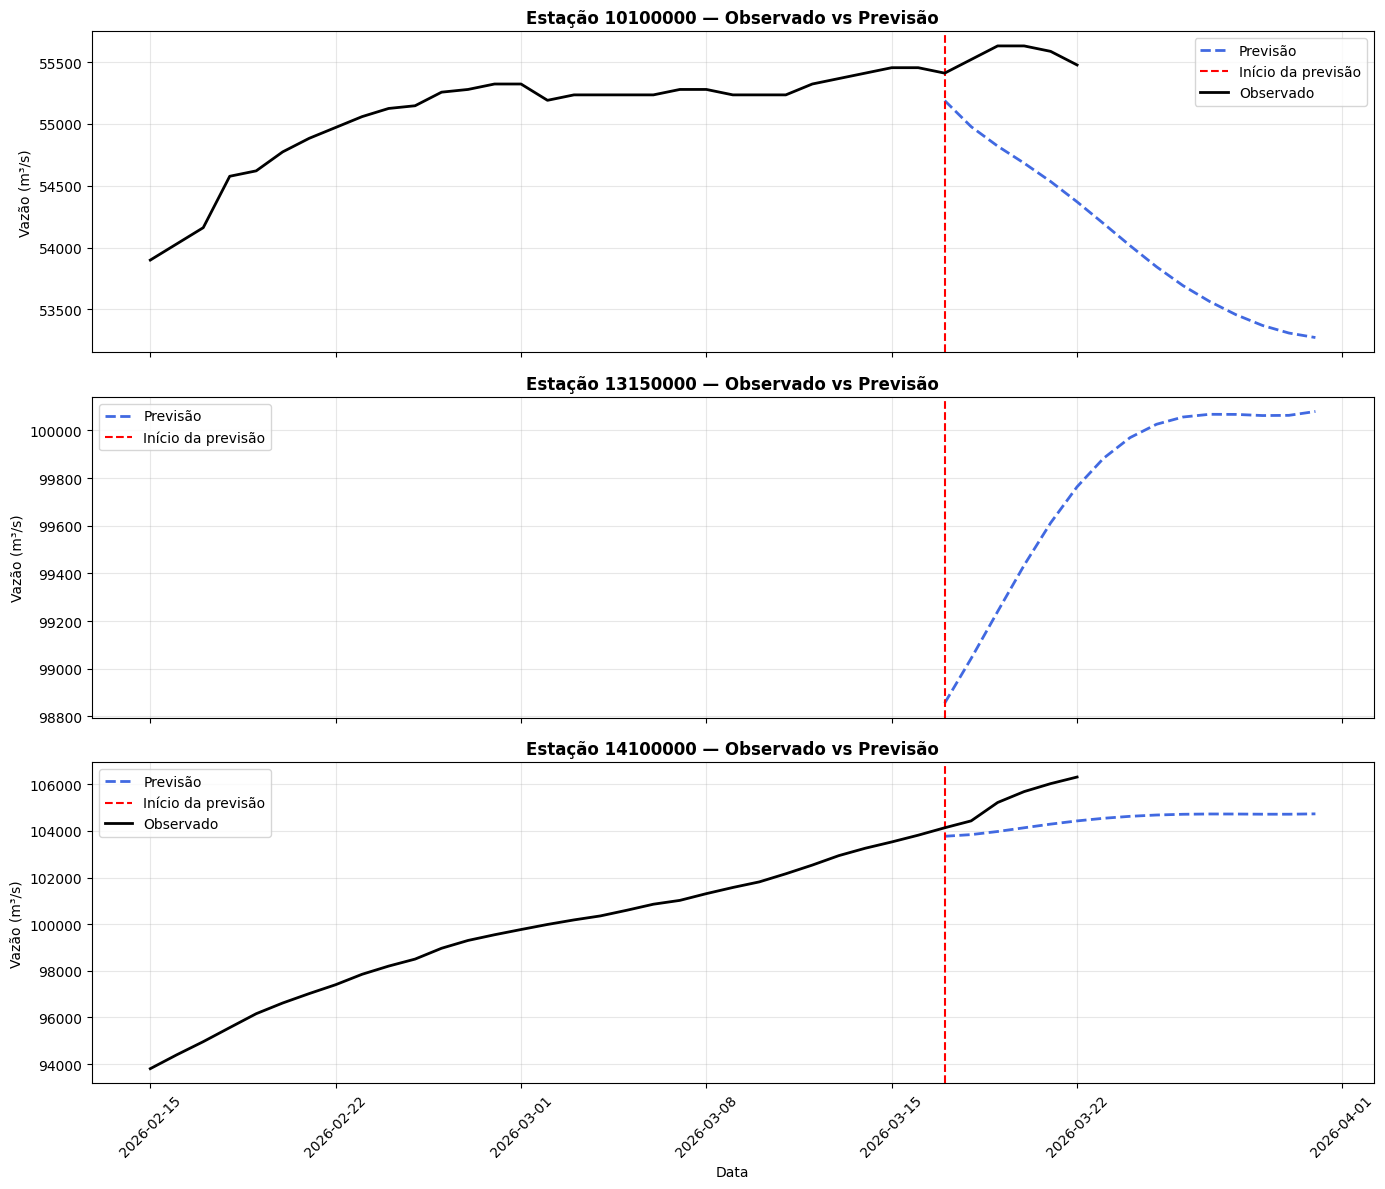

In [58]:
plot_operacional(dados_historicos, previsoes_dict, stations)